In [57]:
#libraries
import numpy as np
import sympy as sp
import sympy.physics.mechanics as me
import matplotlib.pyplot as plt
from anastruct import SystemElements


In [58]:
# variables 
# theta = sp.symbols('theta') # angle of the beam in respect to horizon
# L_h,m_p,g = sp.symbols ('L_h,m_p,g') # Half length, m_p is platform mass, g is gravity 
# rho_ai = sp.symbols('rho_ai') # density of aluminium 
# V_p = sp.symbols ('V_p') # volume of the platform
# A = sp.symbols('A') # cross-sectional area of the beam
# I = sp.symbols('I') # moment of inertia of the beam


def Pin_locator (theta_deg, L, pin_name=None):
   

    theta = np.radians(theta_deg)   # Convert degrees to radians
    x = L*np.cos(theta)
    y = L*np.sin(theta)
    L_h=L/2
    x_h = L_h*np.cos(theta)
    y_h = L_h*np.sin(theta)

    H = np.array([0, L]).astype(float)  
    A = H + np.array([0, -y]).astype(float)  
    P1 = H + np.array([x_h, -y_h]).astype(float)  
    B = A + np.array([x, y]).astype(float)  
    C = H + np.array([x, -y]).astype(float)  
    P2 = B + np.array([x_h, -y_h]).astype(float)  
    E = B + np.array([x, -y]).astype(float)  
    D = C + np.array([x, y]).astype(float)  
     
    
    # Dictionary of all pins
    pins_dict = {'H': H, 'A': A, 'P1': P1, 'B': B, 'C': C, 'P2': P2, 
                 'E': E, 'D': D}
    
    
    if pin_name is None:
        return H, A, P1, B, C, P2, E, D
    else:
        if pin_name not in pins_dict:
            raise ValueError(f"Pin '{pin_name}' not found. Available pins: {list(pins_dict.keys())}")
        
        return pins_dict[pin_name]
    


In [59]:
#plotting 

# def plot_scissor (theta_deg, L=0.140):
#     theta = np.radians(theta_deg)
    
#     # Deriving your variables from a single angle theta
#     # x and y are the full span of one 'X'
#     x = L * np.cos(theta)
#     y = L * np.sin(theta)
#     # x_h and y_h are the half-spans (to the pivot P)
#     x_h, y_h = x/2, y/2

#     # Your Matrix Definitions
#     H = np.array([0, L])
#     A = H + np.array([0, -y])
#     P1 = H + np.array([x_h, -y_h])
#     B = A + np.array([x, y])
#     C = H + np.array([x, -y])
#     P2 = B + np.array([x_h, -y_h])
#     E = B + np.array([x, -y])
#     D = C + np.array([x, y])



#     # Define Bars for plotting
#     bars = [
#         (H, C), (A, B), # Stage 1
#         (B, E), (C, D), # Stage 2
  
#     ]
    
#     plt.figure(figsize=(12, 6))
#     for p1, p2 in bars:
#         plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'o-', color='gray', linewidth=3)
    
#     # Label Points
#     points = {'H':H, 'A':A, 'P1':P1, 'B':B, 'C':C, 'P2':P2, 'D':D, 'E':E}
#     for name, pt in points.items():
#         plt.text(pt[0], pt[1] + 0.2, name, fontsize=, fontweight='bold', ha='center')
#         plt.plot(pt[0], pt[1], 'ko') # Pin markers

#     plt.title(f"Scissor Geometry Verification (theta = {theta_deg}°)")
#     plt.grid(True, linestyle='--')
#     plt.axis('equal')
#     plt.show()

# plot_scissor(25)


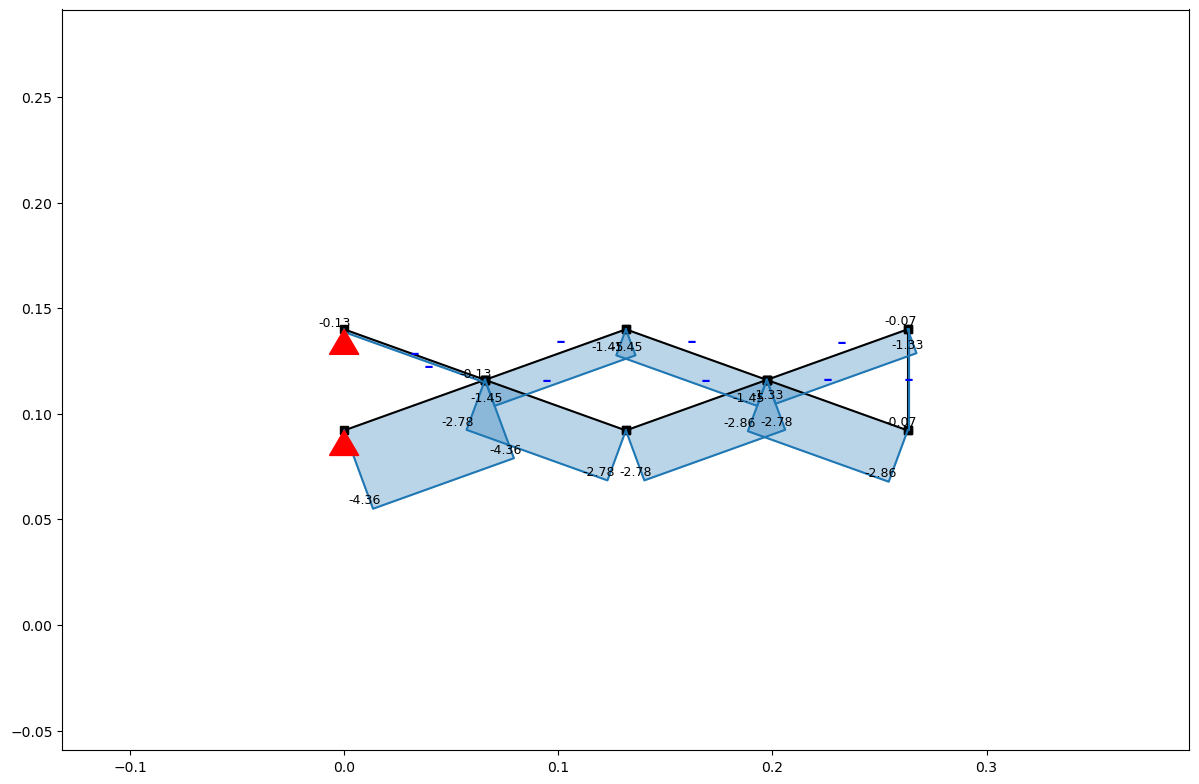

[<Axes: title={'center': 'structure'}>, <Axes: >]


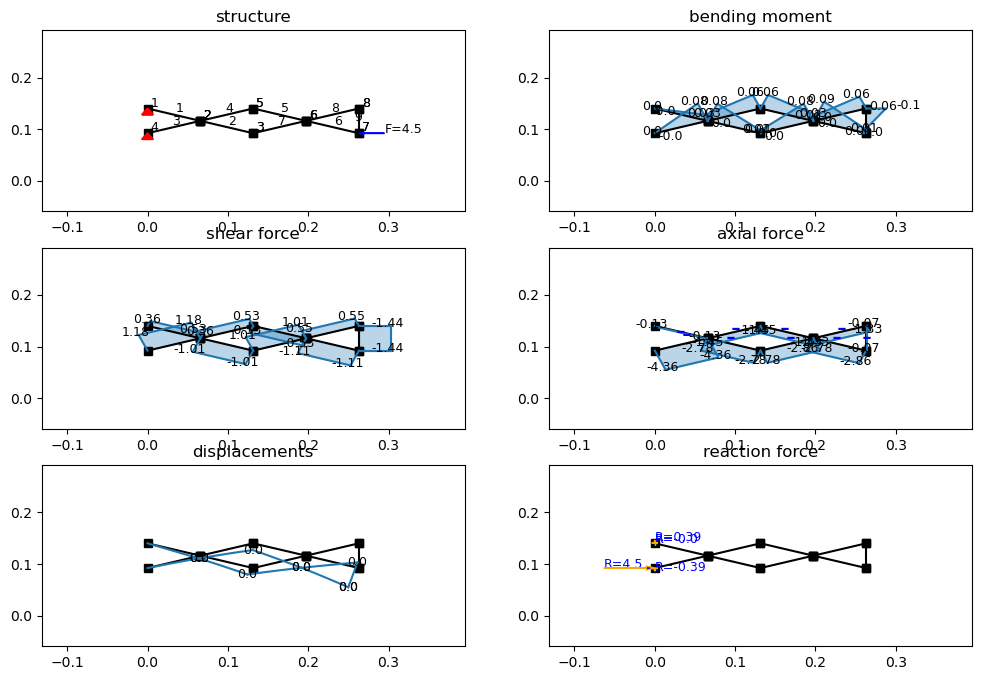

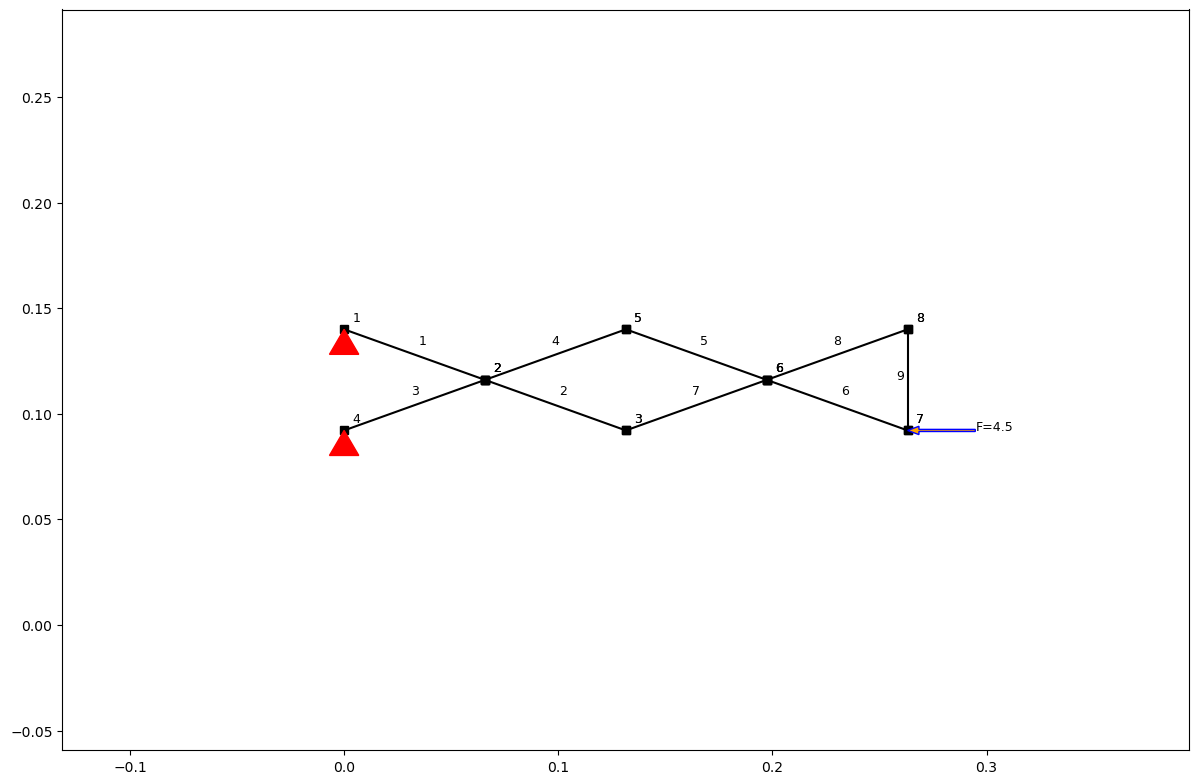

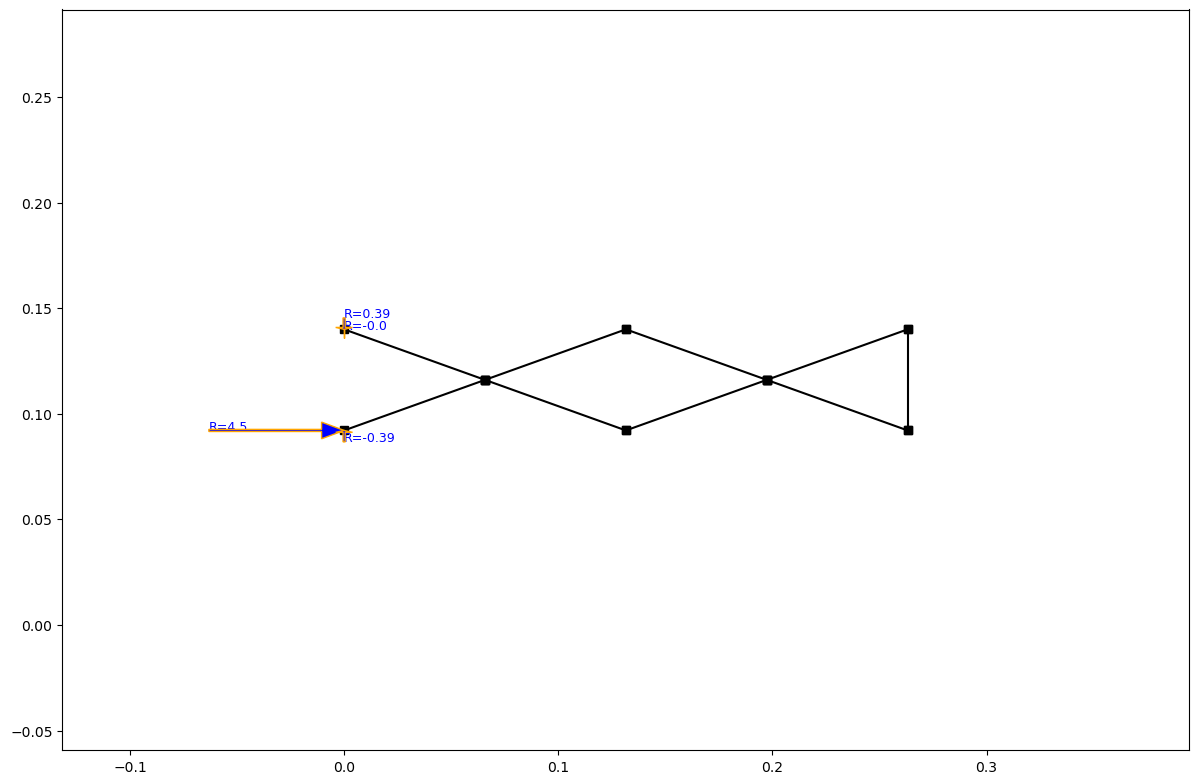

-----------------------------------
Element    | Force (N)    | Type
-----------------------------------
1          | 0.13         | TENSION (+)
2          | 2.78         | TENSION (+)
3          | 4.36         | TENSION (+)
4          | 1.45         | TENSION (+)
5          | 1.45         | TENSION (+)
6          | 2.86         | TENSION (+)
7          | 2.78         | TENSION (+)
8          | 1.33         | TENSION (+)
9          | 0.07         | TENSION (+)
None


In [ ]:

#material PX
E_al = 70e9        # Young's Modulus (Pascals: N/m^2)
rho_al = 2700     # Density (kg/m^3)
A_cs= 0.002513 # Cross-sectional area in m^2
I = 0.00000204204 #(0.09*np.power(0.09,3))/12
g = 9.81

element_type = 'truss'  # Using bar elements for the scissor structure
weight_per_meter = rho_al * A_cs * g

def truss_forces (theta_deg,L,A_cs,E_al,Px,load_at):
    ss = SystemElements(EA=float(E_al*A_cs),EI=float(E_al*I)) 
    pin_names = ['H', 'A', 'P1', 'B', 'C', 'P2', 'E', 'D']
    coords = {name: Pin_locator(theta_deg, L, pin_name=name) for name in pin_names}
    # 3. Define Connectivity (Split at pivots P1, P2, P3)
    elements = [
        ('H', 'P1'), ('P1', 'C'), ('A', 'P1'), ('P1', 'B'), # Stage 1
        ('B', 'P2'), ('P2', 'E'), ('C', 'P2'), ('P2', 'D'), # Stage 2
        ('D', 'E')                                         # Vertical link
    ]# 3. Define Connectivity (Split at pivots P1, P2, P3)
    elements = [
        ('H', 'P1'), ('P1', 'C'), ('A', 'P1'), ('P1', 'B'), # Stage 1
        ('B', 'P2'), ('P2', 'E'), ('C', 'P2'), ('P2', 'D'), # Stage 2
        ('E', 'D')                                         # Vertical link
    ]

    for n1,n2 in elements:
        ss.add_element(location=[coords[n1], coords[n2]],EA=float(E_al*A_cs),EI=float(E_al*I),g=float(weight_per_meter)) #add hinges
    
    id_H = ss.find_node_id(coords['H'])
    id_A = ss.find_node_id(coords['A'])

    ss.add_support_hinged(node_id=id_H) # Add hinged support at H
    ss.add_support_hinged(node_id=id_A) # Add roller support at A (direction = 1 means horizontal)

    ss.point_load(node_id=7,Fx=Px)
    # id_load = ss.find_node_id(coords[load_at])
    # ss.q_load(element_id=9,q=Px)
    # Solve the system
    ss.solve()
    ss.show_axial_force()
    ss.show_results()
    ss.show_structure()
    ss.show_reaction_force()

        # 1. Get the raw range of axial forces
    # This returns a list of values (one for each element)
    axial_forces = ss.get_element_result_range("axial")

    print("-" * 35)
    print(f"{'Element':<10} | {'Force (N)':<12} | {'Type'}")
    print("-" * 35)

    for i, f in enumerate(axial_forces):
        el_id = i + 1
        # Check the sign to determine Tension vs Compression
        if f > 0.001:
            state = "TENSION (+)"
        elif f < -0.001:
            state = "COMPRESSION (-)"
        else:
            state = "ZERO"
        
        print(f"{el_id:<10} | {f:<12.2f} | {state}")

    # 2. Correctly identify the Extremes
    max_tens = np.max(axial_forces)
    max_comp = np.min(axial_forces)

    # print("-" * 35)
    # print(f"CRITICAL TENSION:     {max_tens:.2f} N (Element {np.argmax(axial_forces)+1})")
    # print(f"CRITICAL COMPRESSION: {max_comp:.2f} N (Element {np.argmin(axial_forces)+1})")
    print(ss.get_element_results(element_id=4)['N'])
            
    return ss

# Run and Show
system = truss_forces(20, 0.140, A_cs, E_al,-4.5,'D')  

